In [1]:
import math
from decimal import *
import numpy as np

In [2]:
class Value:
    value_id = 0
    def __init__(self, data, name='', op=''):
        self.data = Decimal(data)
        self.name = name
        self.grad = 0
        self.op = op
        self.children = []
        self.backprop = None
        self.id = Value.value_id
        Value.value_id += 1

    def order_backpropagation(self):
        return self.topo_sort()
    
    def backpropagation_start(self,order):
        self.grad = Decimal(1)
        self.backpropagation(order)

    def backpropagation(self, order_visiting):
        for v in order_visiting:
            if v.backprop:
                v.backprop(*v.children, v.grad)
    
    def __mul__(self, other, op='*'):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, op=op)
        out.children.extend([self, other])

        def backprop(x, y, out_grad):
            x.grad += y.data * out_grad
            y.grad += x.data * out_grad
        out.backprop = backprop
        
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, exp):
        exp = exp.data if isinstance(exp, Value) else Decimal(exp)
        out = Value(math.pow(self.data, exp), op='**')
        out.children.extend([self])
        def backprop(x, out_grad):
            x.grad += exp * Decimal(math.pow(x.data, exp-1)) * out_grad
            
        out.backprop = backprop
        return out
        
    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = self.__mul__(other ** (-1), op='/')
        return out

    def __rtruediv__(self, other):
        other = Value(other)
        return other / self
    
    def __add__(self, other, op='+'):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, op=op)
        out.children.extend([self, other])
        def backprop(x, y, out_grad):
            x.grad += out_grad
            y.grad += out_grad
        out.backprop = backprop
        
        return out

    def log(self, op='log'):
        out = Value(math.log(self.data), op=op)
        out.children.extend([self])
        def backprop(x, out_grad):
            x.grad += (1 / x.data) * out_grad
            
        out.backprop = backprop
        return out

    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = self.__add__(-other, op='-')
        return out

    def __rsub__(self, other):
        return other + (-self)

    def __neg__(self):
        out = Value(-self.data, op='(-)')
        out.children.extend([self])
        def backprop(x, out_grad):
            x.grad += -out_grad
        out.backprop = backprop
            
        return out

    def relu(self):
        out_data = self.data if self.data > 0 else 0
        out = Value(out_data, op='relu')
        out.children.extend([self])
        if self.data > 0:
            self.data = out.data
        def backprop(x, out_grad):
            x.grad +=  out_grad if out.data > 0 else 0
            
        out.backprop = backprop
        return out

    def tanh(self):
        out = Value(math.tanh(self.data), op='tanh')
        out.children.extend([self])
        def backprop(x, out_grad):
            x.grad += (1 - (out.data ** 2)) * out_grad
            
        out.backprop = backprop
        return out

    def sigmoid(self):
        out_data = (1 / (1 + math.exp(-self.data)))
        out = Value(out_data, op='sigmoid')
        out.children.extend([self])
        def backprop(x, out_grad):
            x.grad += (out.data * (1 - out.data)) * out_grad
            
        out.backprop = backprop
        return out

    def copy_value(self):
        v = Value(self.data, name=self.name, op=self.op)
        v.grad = 0
        v.children = self.children
        v.backprop = self.backprop
        v.id = self.value_id
        return v
    
    def __repr__(self):
        return f"Value {self.name} data: {self.data}"

    def __eq__(self, other):
        return self.data == other.data

    def reset_grads(self, order):
        for v in order:
            v.grad = 0

    def topo_sort(self):
        visited = set()
        lst = []
        
        def helper(c):
            if c.id not in visited:
                visited.add(c.id)
                for child in c.children:
                    helper(child)
                lst.append(c)
                
        helper(self)
        lst.reverse()
        return lst

In [3]:
class Neuron:
    def __init__(self, n_inputs, name=''):
        self.weights = np.random.uniform(-1, 1, n_inputs) / np.sqrt(n_inputs)
        self.weights = [[Value(w, name=f'{name} w{i}') for i, w in enumerate(self.weights)]]
        self.name = name
        self.bias = [Value(np.random.uniform(-1, 1), name=f'{self.name} b')]
        self.activation = ''
        self.weights = np.array(self.weights)
        self.bias = np.array(self.bias)

    def forward_propagation(self, inputs):
        assert len(inputs[0]) == len(self.weights[0])
        inputs = np.transpose(np.array(inputs))
        s = np.dot(self.weights, inputs)
        s += self.bias

        if self.activation:
            if self.activation == 'relu':
                output = s.relu()
            elif self.activation == 'tanh':
                output = s.tanh()
            elif self.activation == 'sigmoid':
                output = s.sigmoid()
            return output
            
        return s

    def parameters(self):
        return list(self.weights[0]) + list(self.bias)
        
    def add_activation(self, activation):
        self.activation = activation

    def __repr__(self):
        return f"Neuron:{self.name} activation: {self.activation}"
    def __call__(self, x):
        return self.forward_propagation(x)

class Layer:
    def __init__(self, n_neurons, n_inputs, name=''):
        self.name = name
        self.neurons = [Neuron(n_inputs, f"{self.name}n{i}") for i, _ in enumerate(range(n_neurons))]
        self.weights = []
        self.biases = []
        for n in self.neurons:
            self.weights.extend(n.weights)
            self.biases.append(n.bias)
        self.weights = np.array(self.weights)
        self.biases = np.array(self.biases)
        self.activation = ''

    def forward_propagation(self, inputs):
        res = np.dot(self.weights, inputs) + self.biases
        outputs = []
        if self.activation == 'relu':
            for i in range(len(res)):
                outputs.append([])
                for j in range(len(res[0])):
                    outputs[-1].append(res[i][j].relu())

        elif self.activation == 'tanh':
            for i in range(len(res)):
                outputs.append([])
                for j in range(len(res[0])):
                    outputs[-1].append(res[i][j].tanh())

        elif self.activation == 'sigmoid':
            for i in range(len(res)):
                outputs.append([])
                for j in range(len(res[0])):
                    outputs[-1].append(res[i][j].sigmoid())
        else:
            outputs = res
                    
        outputs = np.array(outputs)
        return outputs

    def add_activation(self, activation):
        activations = ['relu', 'tanh', 'sigmoid']
        if activation not in activations:
            print('Tried to add unknown activation')
            return
        self.activation = activation
        for neuron in self.neurons:
            neuron.add_activation(activation)

    def parameters(self):
        p = []
        for neuron in self.neurons:
            p.extend(neuron.parameters())
        return p

    def __repr__(self):
        return f"Layer: {self.name} - {[n for n in self.neurons]}"

    def __call__(self, x):
        res = self.forward_propagation(x)
        if len(res) == 1:
            return res[0]
        return res

class MLP:
    def __init__(self, start_input_size, name=''):
        self.name = name
        self.inputs = [start_input_size]
        self.layers = []
        self.loss_function = ''

    def add(self, n_neurons, activation=''):
        self.layers.append(Layer(n_neurons, self.inputs[-1], f'l{len(self.layers)}'))
        self.inputs.append(n_neurons)
        if activation:
            self.layers[-1].add_activation(activation)

    def forward_propagation(self, inputs):
        inputs = np.transpose(np.array(inputs))
        output = inputs
        for layer in self.layers:
            output = layer.forward_propagation(output)
        return output

    def compile(self, loss_function, learning_rate = 0.001):
        self.learning_rate = Decimal(learning_rate)
        loss_functions = ['MSE', 'MAE', 'BinaryCrossentropy']
        assert loss_function in loss_functions
        self.loss_function = loss_function

    def fit(self, X, Y, is_gradient_checking=False):
        processed_inputs = []
        for lst in X:
            processed_inputs.append([Value(v) for v in lst])

        outputs = self.forward_propagation(X)
        outputs = outputs.T
        losses = []
        for i, output in enumerate(outputs):
            if self.loss_function == 'MSE':
                res = self.MSE(Y[i], output)
            elif self.loss_function == 'MAE':
                res = self.MAE(Y[i], output)
            elif self.loss_function == 'BinaryCrossentropy':
                res = self.BinaryCrossentropy(Y[i], output)
            losses.append(res)
            
        total_loss = losses[0]
        for loss in losses[1:]:
            total_loss += loss
        order = total_loss.order_backpropagation()
        losses[0].reset_grads(order)
        total_loss.backpropagation_start(order)
        if not is_gradient_checking:
            self.update_weights(order)

    def update_weights(self, order):
        for v in order:
            v.data += -self.learning_rate * v.grad

    def parameters(self):
        p = []
        for layer in self.layers:
            p.extend(layer.parameters())
        return p
        
    def MSE(self, y_true, y_pred):
        y_pred = np.array(y_pred).flatten()
        n = len(y_true)
        total = Value(0)
        for i in range(len(y_true)):
            total += (y_true[i] - y_pred[i]) ** 2
        return total / n

    def MAE(self, y_true, y_pred):
        y_pred = np.array(y_pred).flatten()
        n = len(y_true)
        total = Value(0)
        for i in range(len(y_true)):
            if y_true[i] > y_pred[i].data:
                total += y_true[i] - y_pred[i]
            else:
                total += y_pred[i] - y_true[i]
        return total / n

    def BinaryCrossentropy(self, y_true, y_pred):
        y_pred = np.array(y_pred).flatten()
        n = len(y_true)
        total = Value(0)
        eps = Decimal('1e-5')
        for i in range(len(y_true)):
            if y_pred[i].data == 0:
                y_pred[i] += eps
            elif y_pred[i].data == 1:
                y_pred[i] -= eps
            total += (y_true[i] * y_pred[i].log()) + ((1 - y_true[i]) * (1 - y_pred[i]).log())
        return total / (-n)
    
    def __repr__(self):
        return f"Layer: {self.name} - {[l for l in self.layers]}"
    def __call__(self, x):
        return self.forward_propagation(x)

In [4]:
# HELPER LOSS FUNCTIONS FOR TESTING

def MSE(y_true, y_pred):
    y_pred = np.array(y_pred).flatten()
    n = len(y_true)
    total = Value(0)
    for i in range(len(y_true)):
        total += (y_true[i] - y_pred[i]) ** 2
    return total / n

def MAE(y_true, y_pred):
    y_pred = np.array(y_pred).flatten()
    n = len(y_true)
    total = Value(0)
    for i in range(len(y_true)):
        if y_true[i] > y_pred[i].data:
            total += y_true[i] - y_pred[i]
        else:
            total += y_pred[i] - y_true[i]
    return total / n

def BinaryCrossentropy(y_true, y_pred):
    y_pred = np.array(y_pred).flatten()
    n = len(y_true)
    total = Value(0)
    eps = Decimal('1e-5')
    for i in range(len(y_true)):
        if y_pred[i].data == 0:
            y_pred[i] += eps
        elif y_pred[i].data == 1:
            y_pred[i] -= eps
        total += (y_true[i] * y_pred[i].log()) + ((1 - y_true[i]) * (1 - y_pred[i]).log())
    return total / (-n)

In [5]:
# HELPER CODE FOR GRADIENT CHECKING 

def gradient_checking_information_print(loss_function_name, activations, activations_idx, n_layers, n_neurons):
    print(f'Loss function used: {loss_function_name}')
    print(f'Number of layers: {n_layers}')
    print('Layers:------------------------')
    for i in range(n_layers):
        print(f'Layer {i+1} has {n_neurons[i]} neurons with activation: {activations[activations_idx[i]]}')
    print('-------------------------------')

In [6]:
n_input = np.random.randint(low=1, high=8)
n_input_samples = np.random.randint(low=1, high=10)
inputs = np.random.rand(n_input_samples, n_input)
labels = np.ones((n_input_samples, 1))
n_layers = np.random.randint(low=1, high=6)
n_neurons = np.random.randint(low=1, high=10, size=n_layers)
activations_idx = np.random.randint(low=0, high=3, size=n_layers)
loss_function_name_idx = np.random.randint(low=0, high=3)
activations = ['relu', 'tanh', 'sigmoid']
loss_function_possible_names = ['MSE', 'MAE', 'BinaryCrossentropy']
loss_function_name = loss_function_possible_names[loss_function_name_idx]
loss_function = None
if loss_function_name == 'MSE':
    loss_function = MSE
elif loss_function_name == 'MAE':
    loss_function = MAE
elif loss_function_name == 'BinaryCrossentropy':
    loss_function = BinaryCrossentropy
    activations_idx[-1] = 2
    n_neurons[-1] = 1

gradient_checking_information_print(loss_function_name, activations, activations_idx, n_layers, n_neurons)
m = MLP(n_input)
for n_neuron, activation_idx in zip(n_neurons, activations_idx):
    m.add(n_neuron, activations[activation_idx])

m.compile(loss_function_name)
m.fit(inputs, labels, is_gradient_checking=True)
    
# # SAVING THE GRADIENTS CALCULATED USING BACKPROPAGATION
backprop_grads = []
for layer in m.layers:
    for neuron in layer.neurons:
        for w in neuron.weights[0]:
            backprop_grads.append(w.grad)
        backprop_grads.append(neuron.bias[0].grad)
# # MANUALLY CALCULATING THE GRADIENTS

def calc_grad(m, eps, inputs, labels, p):
    calc_grad = Value(0)
    for i in range(len(inputs)):
        sample = inputs[i].reshape(1, -1)
        p.data += eps
        res_add_eps = m.forward_propagation(sample)
        mse_add_eps = loss_function(labels[i], res_add_eps)
        p.data -= 2 * eps
        res_minus_eps = m.forward_propagation(sample)
        mse_minus_eps= loss_function(labels[i], res_minus_eps)
        calc_grad += (mse_add_eps - mse_minus_eps) / (2 * eps)
        p.data += eps
    return calc_grad

eps = Decimal('1e-5')
manual_gradients = []

for layer in m.layers:
    for neuron in layer.neurons:
        for w in neuron.weights[0]:
            manual_gradients.append(calc_grad(m, eps, inputs,labels, w).data)
        # checking the bias
        bias = neuron.bias[0]
        manual_gradients.append(calc_grad(m, eps, inputs, labels, bias).data)

# # Compare with gradients

distance = Decimal('1e-5')
is_valid = True

for manual_gradient, backprop_gradient in zip(manual_gradients, backprop_grads):
    if not(backprop_gradient > manual_gradient - distance and backprop_gradient < manual_gradient + distance):
        is_valid = False
        print(f'FOUND A PROBLEM')
        print(f'manual gradient: {manual_gradient}')
        print(f'backprop gradient: {backprop_gradient}')

if not is_valid:
    print(f'There is a problem with the gradients')
else:
    print(f'No problem with the gradients')

Loss function used: BinaryCrossentropy
Number of layers: 4
Layers:------------------------
Layer 1 has 4 neurons with activation: tanh
Layer 2 has 4 neurons with activation: sigmoid
Layer 3 has 4 neurons with activation: relu
Layer 4 has 1 neurons with activation: sigmoid
-------------------------------
No problem with the gradients


In [7]:
n_layers = np.random.randint(low=2, high=7)
n_neurons = np.random.randint(low=2, high=7, size=n_layers)
n_input = np.random.randint(low=1, high=10)
demo_input = np.random.rand(1, n_input)
m = MLP(n_input)
for n in n_neurons:
    m.add(n)

m_res = m.forward_propagation(demo_input)
m_res = [float(v.data) for v in m_res.flatten()]

calc_res = m.layers[0].forward_propagation(np.transpose(demo_input))
for layer in m.layers[1:]:
    calc_res = layer.forward_propagation(calc_res)
calc_res = [float(v.data) for v in calc_res.flatten()]

if m_res != calc_res:
    print(f'Problem with MLP forward propagation\nMLP res = {m_res}\ncalc_res = {calc_res}')
else:
    print(f'No Problem with MLP forward propagation')

No Problem with MLP forward propagation


In [8]:
n_neurons = np.random.randint(low=1, high=20)
n_input = np.random.randint(low=1, high=15)
demo_input = np.random.rand(n_input, 1)
l = Layer(n_neurons, n_input)

layer_res = l.forward_propagation(demo_input)
layer_res = [float(v.data) for v in layer_res.flatten()]

s = []
for neuron in l.neurons:
    res = neuron.forward_propagation(demo_input.T)
    s.append(float(np.array(res).flatten()[0].data))

is_valid = True
for i, (neuron_res, actual_res) in enumerate(zip(layer_res, s)):
    if neuron_res != actual_res:
        print(f'Problem with layer forward propagation neural result: {neuron_res} calc result: {actual_res}')
        is_valid = False
if is_valid:
    print('No Problem with Layer forward propagation')
else:
    print('Found Problems with Layer forward propagation')

No Problem with Layer forward propagation


In [9]:
n_input = np.random.randint(low=1, high=20)
demo_input = np.random.rand(1, n_input)
n = Neuron(n_input)

n_res = n.forward_propagation(demo_input)
n_res = np.array(n_res).flatten()[0]

weights = n.weights[0]
bias = n.bias[0]
s = Value(0)
for i in range(len(weights)):
    s += weights[i] * demo_input[0][i]
s += bias

if float(s.data) != float(n_res.data):
    print(f'Problem with Neuron forward propagation\n neural result: {n_res}\n calc result: {s}')
else:
    print('No Problem with Neuron forward propagation')

No Problem with Neuron forward propagation


In [10]:
a = Value(2, 'a')
b = Value(9, 'b')

# TESTING BASIC FUNCTIONS
b1 = ' With Number Before'
b2 = ' With Number After'

operations_names_orig = ['Addition', 'Subtraction', 'Division', 'Multiplication']
operations_names = operations_names_orig[:] + ['Power', 'Negation']
operations_names.extend([p + b1 for p in operations_names_orig])
operations_names.extend([p + b2 for p in operations_names_orig])
operations_names.append('Power' + b2)
operations_names.append('Logarithms')
c = 4

calc_res = [a+b, a-b, a/b, a*b, a**b, -a,
           c+a, c-b, c/b, c*b,
           a+c, b-c, b/c, b*c, b**c, b.log()]

actual_res = [11, -7, 2/9, 18, 2**9, -2,
             6, -5, 4/9, 36,
             6, 5, 9/4, 36, 9**4, math.log(9)]

actual_res = map(lambda x: Value(x), actual_res)

is_valid = True
for i, (x, y) in enumerate(zip(calc_res, actual_res)):
    if (float(x.data) != float(y.data)):
        is_valid = False
        print(f"Didn't pass {operations_names[i]}")

print("---------")
if(is_valid):
    print("SUCCESSFULLY PASSED ALL TEST")
else:
    print("DIDN'T SUCCESSFULLY PASSED ALL TESTS")
print("---------")

---------
SUCCESSFULLY PASSED ALL TEST
---------


In [11]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
# My example, using make_circles
np.random.seed(42)
random.seed(42)

# CONSTANTS
ITERATIONS = 100
LEARNING_RATE = 1
DECAY_RATE = 0.9

In [13]:
# Importing data from toy dataset, importing shapes
from sklearn.datasets import make_circles
X, y = make_circles(200, shuffle=True, noise=0.1, random_state=42, factor=0.6)
y = np.array([1 if yy == 1 else -1 for yy in y])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (200, 2)
y shape: (200,)


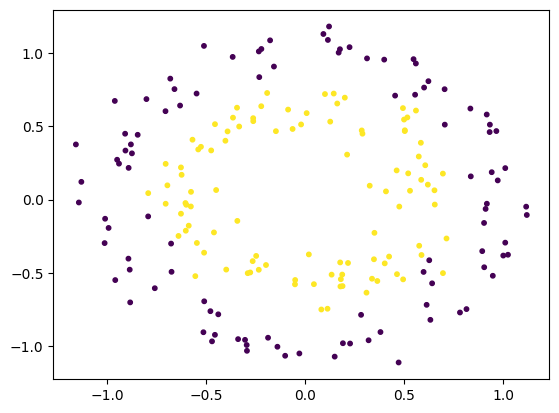

In [14]:
# Data visualization
plt.scatter(X[:,0],X[:,1], s=10, c=y)

In [15]:
# Initializing model
model = MLP(2)
model.add(16, 'relu')
model.add(16, 'relu')
model.add(1)

print(f"number of parameters: {len(model.parameters())}")
print(f"model: {model}")

number of parameters: 337
model: Layer:  - [Layer: l0 - [Neuron:l0n0 activation: relu, Neuron:l0n1 activation: relu, Neuron:l0n2 activation: relu, Neuron:l0n3 activation: relu, Neuron:l0n4 activation: relu, Neuron:l0n5 activation: relu, Neuron:l0n6 activation: relu, Neuron:l0n7 activation: relu, Neuron:l0n8 activation: relu, Neuron:l0n9 activation: relu, Neuron:l0n10 activation: relu, Neuron:l0n11 activation: relu, Neuron:l0n12 activation: relu, Neuron:l0n13 activation: relu, Neuron:l0n14 activation: relu, Neuron:l0n15 activation: relu], Layer: l1 - [Neuron:l1n0 activation: relu, Neuron:l1n1 activation: relu, Neuron:l1n2 activation: relu, Neuron:l1n3 activation: relu, Neuron:l1n4 activation: relu, Neuron:l1n5 activation: relu, Neuron:l1n6 activation: relu, Neuron:l1n7 activation: relu, Neuron:l1n8 activation: relu, Neuron:l1n9 activation: relu, Neuron:l1n10 activation: relu, Neuron:l1n11 activation: relu, Neuron:l1n12 activation: relu, Neuron:l1n13 activation: relu, Neuron:l1n14 activa

In [16]:
# Loss function
def loss():
    inputs = [list(map(Value, xrow)) for xrow in X]
    
    # Calculating predictions
    scores = list(model(inputs).flatten())

    # Data loss
    losses = [(1 - yi*scorei).relu() for yi, scorei in zip(y, scores)]
    data_loss = sum(losses) / len(losses)

    # L2 Loss
    alpha = 1e-4
    reg_loss = alpha * sum([p*p for p in model.parameters()])

    # Total loss and Accuracy
    total_loss = data_loss + reg_loss
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(y, scores)]
    return total_loss, sum(accuracy) / len(accuracy)
    
total_loss, acc = loss()
print(f"loss: {total_loss} accuracy {acc*100}%")

loss: Value  data: 1.006859074226887364305840827 accuracy 50.0%


In [17]:
# Fitting the model
for k in range(ITERATIONS):
    # Calculating the loss and then backpropagating
    total_loss, acc = loss()
    order = total_loss.order_backpropagation()
    total_loss.reset_grads(order)

    total_loss.backpropagation_start(order)
    
    # Learning rate decay
    learning_rate = Decimal(1.0 - DECAY_RATE*k/ITERATIONS)

    # Updating weights and biases
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    if k % 5 == 0:
        print(f"step {k} loss {total_loss.data:.8f}, accuracy {acc*100}%")

step 0 loss 1.00685907, accuracy 50.0%
step 5 loss 0.98746049, accuracy 50.0%
step 10 loss 0.95626634, accuracy 53.0%
step 15 loss 0.87476749, accuracy 60.0%
step 20 loss 0.79015447, accuracy 56.99999999999999%
step 25 loss 0.72687550, accuracy 68.5%
step 30 loss 0.77111870, accuracy 59.5%
step 35 loss 0.69542333, accuracy 66.0%
step 40 loss 0.48557776, accuracy 82.0%
step 45 loss 0.72793088, accuracy 63.0%
step 50 loss 0.59480100, accuracy 70.5%
step 55 loss 0.45935750, accuracy 77.0%
step 60 loss 0.44562173, accuracy 78.0%
step 65 loss 0.31711605, accuracy 87.5%
step 70 loss 0.26089302, accuracy 93.0%
step 75 loss 0.19639223, accuracy 93.0%
step 80 loss 0.16105258, accuracy 95.5%
step 85 loss 0.12653388, accuracy 95.5%
step 90 loss 0.11894773, accuracy 95.5%
step 95 loss 0.11389073, accuracy 95.5%


In [18]:
# Creating a uniform grid for countourf
h = 0.1
x_min, x_max = X[:,0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Combining xx and yy into their corresponding tuples
xxyy = np.c_[xx.ravel(), yy.ravel()]

# Calculating corresponding scores and reshaping to fit xx
scores = list(model(xxyy).flatten())
scores = [scorei.data > 0 for scorei in scores]
scores = np.reshape(scores, xx.shape)

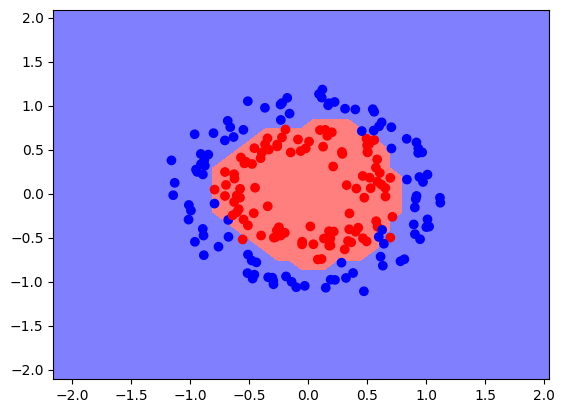

In [19]:
# plotting background and then plotting X and y
plt.contourf(xx, yy, scores, cmap='bwr')
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')

In [20]:
# Micrograd example
np.random.seed(1337)
random.seed(1337)

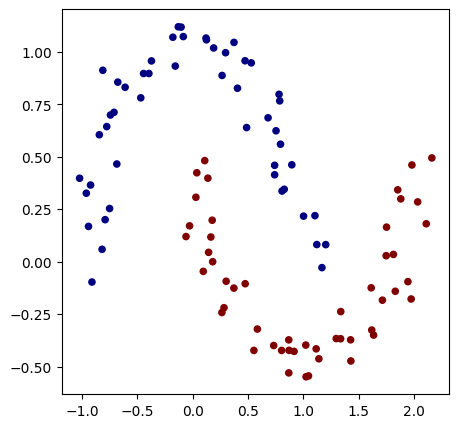

In [21]:
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1

plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [22]:
model = MLP(2)
model.add(16, activation='relu')
model.add(16, activation='relu')
model.add(1)
print(len(model.parameters()))
print(model)

337
Layer:  - [Layer: l0 - [Neuron:l0n0 activation: relu, Neuron:l0n1 activation: relu, Neuron:l0n2 activation: relu, Neuron:l0n3 activation: relu, Neuron:l0n4 activation: relu, Neuron:l0n5 activation: relu, Neuron:l0n6 activation: relu, Neuron:l0n7 activation: relu, Neuron:l0n8 activation: relu, Neuron:l0n9 activation: relu, Neuron:l0n10 activation: relu, Neuron:l0n11 activation: relu, Neuron:l0n12 activation: relu, Neuron:l0n13 activation: relu, Neuron:l0n14 activation: relu, Neuron:l0n15 activation: relu], Layer: l1 - [Neuron:l1n0 activation: relu, Neuron:l1n1 activation: relu, Neuron:l1n2 activation: relu, Neuron:l1n3 activation: relu, Neuron:l1n4 activation: relu, Neuron:l1n5 activation: relu, Neuron:l1n6 activation: relu, Neuron:l1n7 activation: relu, Neuron:l1n8 activation: relu, Neuron:l1n9 activation: relu, Neuron:l1n10 activation: relu, Neuron:l1n11 activation: relu, Neuron:l1n12 activation: relu, Neuron:l1n13 activation: relu, Neuron:l1n14 activation: relu, Neuron:l1n15 acti

In [23]:
def loss(batch_size=None):
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    scores = list(model(inputs).flatten())
    losses = [(1 + -yi * scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    alpha = 1e-4
    reg_loss = alpha * sum((p * p for p in model.parameters()))
    total_loss = data_loss + reg_loss
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)

Value  data: 0.9851254597941946431291908507 0.5


In [24]:
for k in range(100):
    total_loss, acc = loss()
    order = total_loss.order_backpropagation()
    total_loss.reset_grads(order)

    total_loss.backpropagation_start(order)
    learning_rate = Decimal(1.0 - 0.9*k/100)
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

step 0 loss 0.9851254597941946431291908507, accuracy 50.0%
step 1 loss 0.9115294361078433855564405179, accuracy 50.0%
step 2 loss 0.7856819923626805926309331328, accuracy 50.0%
step 3 loss 0.6593392331533519265953610533, accuracy 71.0%
step 4 loss 1.293762132658834336247307052, accuracy 50.0%
step 5 loss 0.5904069562535274124642905906, accuracy 80.0%
step 6 loss 0.5975042726833646888832651039, accuracy 80.0%
step 7 loss 0.4247250390647251157801119132, accuracy 81.0%
step 8 loss 0.3263148493852900474702941741, accuracy 85.0%
step 9 loss 0.2929403320834671750104713018, accuracy 88.0%
step 10 loss 0.2779311751153021191861634381, accuracy 88.0%
step 11 loss 0.2673494495116401919065621579, accuracy 89.0%
step 12 loss 0.2641946025534224906809556432, accuracy 88.0%
step 13 loss 0.2651350754897776265512637886, accuracy 90.0%
step 14 loss 0.2664017494850257891836894867, accuracy 89.0%
step 15 loss 0.2843191741952762153391501310, accuracy 88.0%
step 16 loss 0.2808958329901909675209795257, accura

(-1.548639298268643, 1.951360701731357)

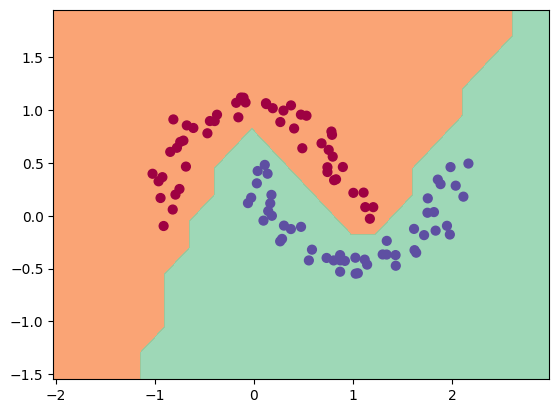

In [25]:
h=0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(model(inputs).flatten())
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())